# Descriptive stats of raw data

In [33]:
import pandas as pd
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [34]:
# def set_style():
#     # Use a base style (optional)
#     plt.style.use("ggplot")  # Or "seaborn-whitegrid", etc.
    
#     # Set global rcParams
#     plt.rcParams.update({
#         "figure.figsize": (10, 6),
#         "axes.titlesize": 16,
#         "axes.labelsize": 14,
#         #"axes.grid": True,
#         #"grid.alpha": 0.3,
#         #"grid.linestyle": "--",
#         "axes.facecolor": "white",  # Set axes background to white
#         "axes.edgecolor": "black",  # Set axes edge color
#         "xtick.labelsize": 12,
#         "ytick.labelsize": 12,
#         "legend.fontsize": 12,
#         "font.family": "serif",
#         "savefig.dpi": 300,
#         "figure.autolayout": True
#     })

# #set_style()

In [40]:
pro_df = pd.read_csv('pro_media.csv')
sci_df = pd.read_csv('sci_media.csv')
reg_df = pd.read_csv('reg_media.csv')

texts = {'Proffessional': pro_df['Content'],
         'Scientific': sci_df['Content'],
         'Regional': reg_df['Content']}

All the texts contain a number of texts. I want to generate descriptive statistics with the columns described below

Create a table with 

Source | Number of documents | Average characters pr. document | Distinct words in whole corpus of source

In [41]:


def calculate_stats(texts):
    stats = []
    for source, content in texts.items():
        num_docs = len(content)
        avg_words = content.str.split().apply(len).mean()  
        total_words = sum(content.str.split().apply(len))
        distinct_words = len(set(' '.join(content).split()))
        stats.append({'Source': source, 
                      'Number of documents': num_docs, 
                      'Average characters pr. document': avg_words, 
                      'Total words in whole corpus of source': total_words, 
                      'Distinct words in whole corpus of source': distinct_words})
    return pd.DataFrame(stats)



stats_df = calculate_stats(texts)
stats_df['Language'] = ['DA', 'EN', 'DA']
print(stats_df)



          Source  Number of documents  Average characters pr. document  \
0  Proffessional                  187                       909.181818   
1     Scientific                  559                       182.914132   
2       Regional                  682                       729.114370   

   Total words in whole corpus of source  \
0                                 170017   
1                                 102249   
2                                 497256   

   Distinct words in whole corpus of source Language  
0                                     23402       DA  
1                                     12569       EN  
2                                     43649       DA  


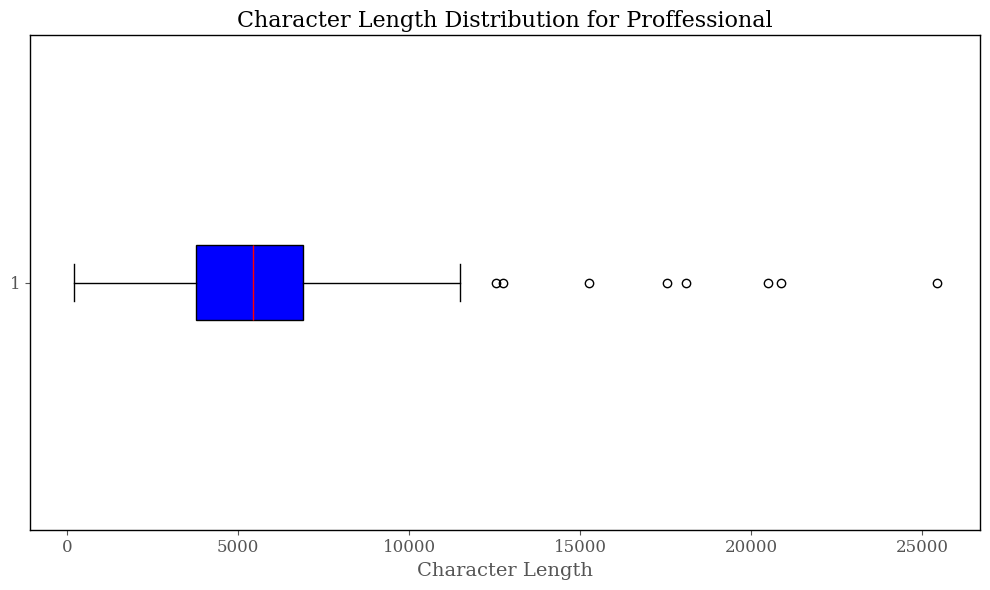

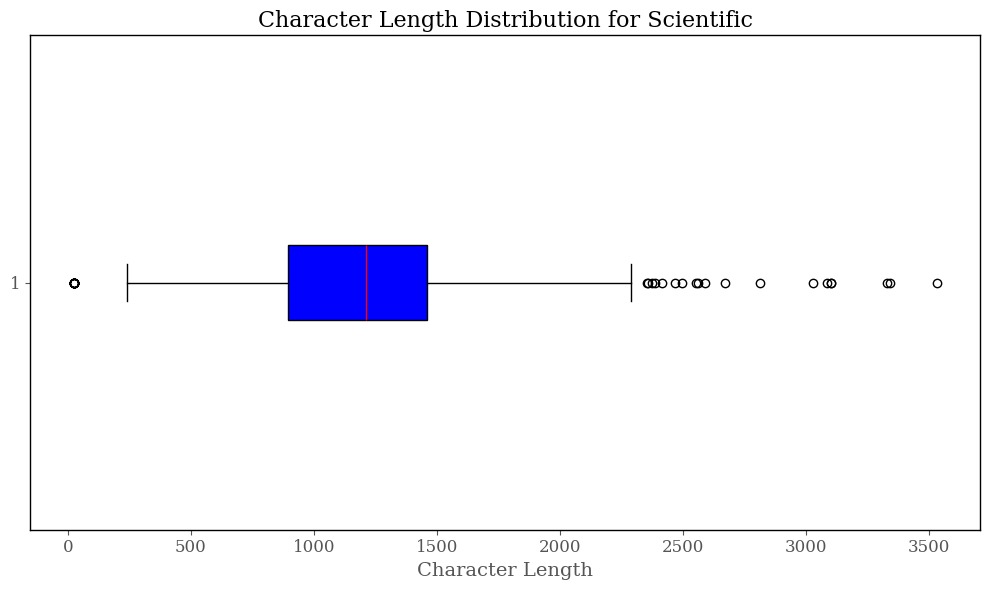

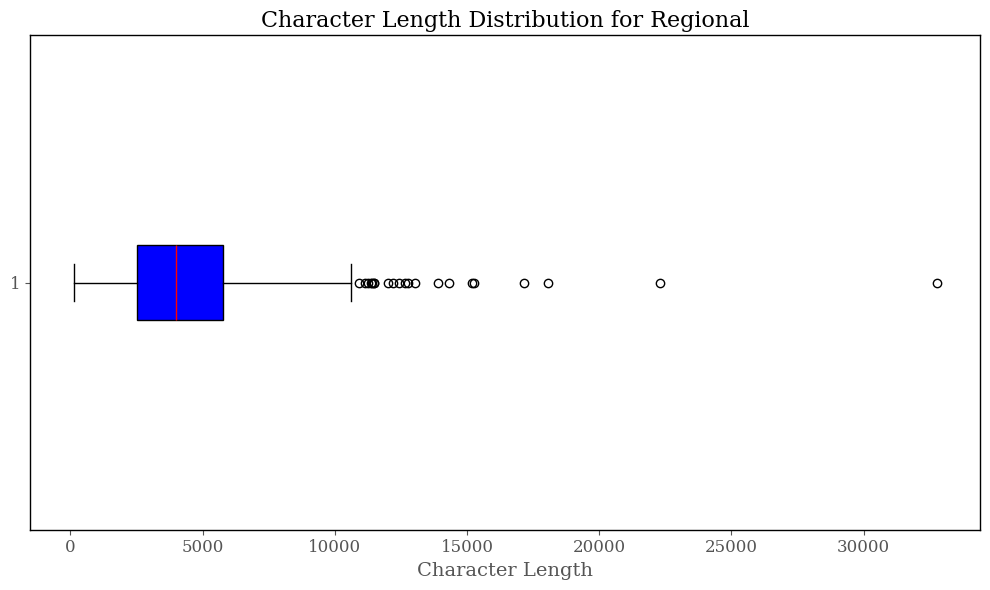

In [42]:
def plot_character_length_distribution(texts):
    for source, content in texts.items():
        char_lengths = content.str.len()
        plt.figure(figsize=(10, 6))
        plt.boxplot(char_lengths.dropna(), vert=False, patch_artist=True, 
                    boxprops=dict(facecolor='blue', color='black'),
                    medianprops=dict(color='red'))
        plt.title(f'Character Length Distribution for {source}')
        plt.xlabel('Character Length')
        plt.grid(axis='x', alpha=0.75)
        plt.show()
        
plot_character_length_distribution(texts)

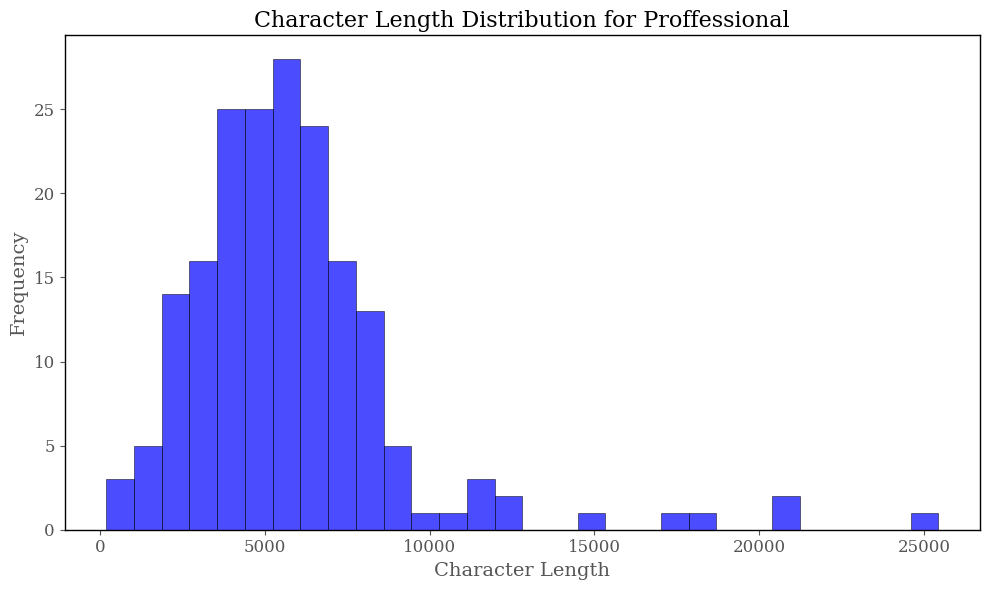

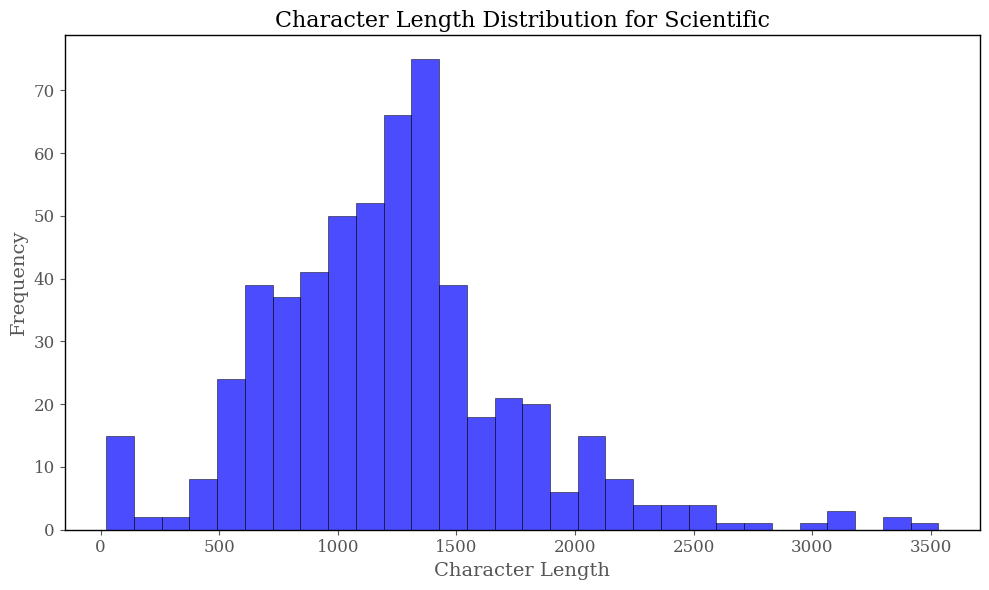

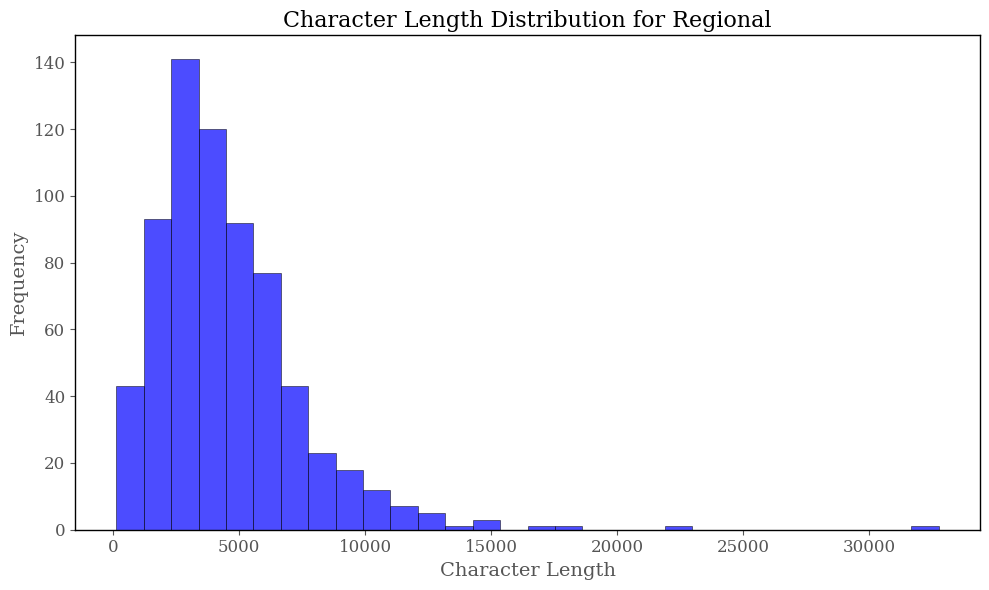

In [43]:
def plot_character_length_distribution(texts):
    for source, content in texts.items():
        char_lengths = content.str.len()
        plt.figure(figsize=(10, 6))
        plt.hist(char_lengths, bins=30, alpha=0.7, color='blue', edgecolor='black')
        plt.title(f'Character Length Distribution for {source}')
        plt.xlabel('Character Length')
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.75)
        plt.show()
        
plot_character_length_distribution(texts)

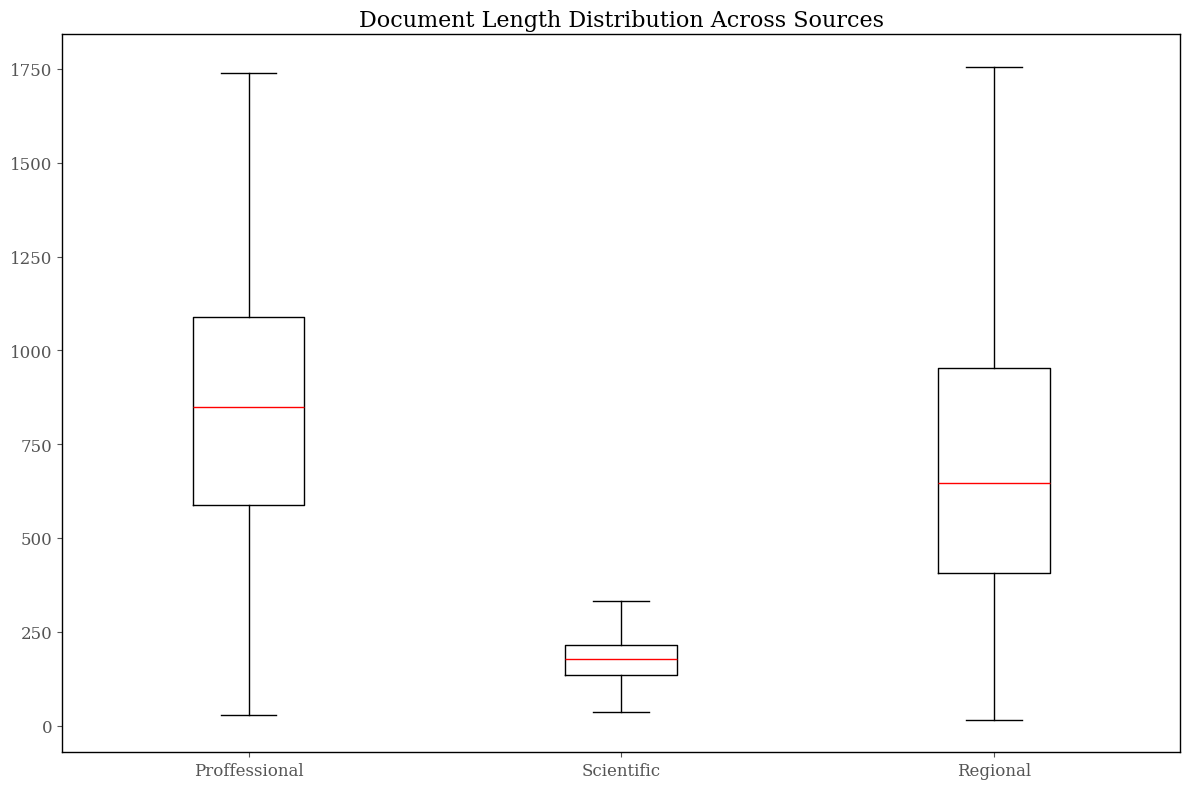

In [48]:
def plot_combined_character_length_distribution(texts):
    plt.figure(figsize=(12, 8))
    data = []
    labels = []
    for source, content in texts.items():
        char_lengths = content.str.split().apply(len).dropna()
        data.append(char_lengths)
        labels.append(source)
    plt.boxplot(data, #vert=False, patch_artist=True, 
                #boxprops=dict(facecolor='blue', color='black'),
                medianprops=dict(color='red'),
                showfliers=False)  # Exclude outliers
    plt.title('Document Length Distribution Across Sources')
    #plt.xlabel('Document Length')
    plt.xticks(range(1, len(labels) + 1), labels)
    plt.grid(axis='x', alpha=0.75)
    plt.show()

plot_combined_character_length_distribution(texts)